# **Feature Engineering Notebook**

## Objectives

* Engineer features for Classification and Cluster models. 

## Inputs

* inputs/datasets/cleaned/TrainSet.csv
* inputs/datasets/cleaned/TestSet.csv

## Outputs

* Generate list of variables to engineer

---

# Set working directory

In [3]:
import os
current_dir = os.getcwd()
os.chdir(os.path.dirname(current_dir))
current_dir = os.getcwd()
current_dir

'/workspaces/airline-delay-predictor'

---

# Load Clean Data

**Train Set**

In [4]:
import pandas as pd
train_set_path = "outputs/datasets/cleaned/TrainSetCleaned.csv"
TrainSet = pd.read_csv(train_set_path)
TrainSet.head(5)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,DEPARTURE_DELAY,DISTANCE,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,flight_depart_delayed,AIR_SYSTEM_DELAY_pct,SECURITY_DELAY_pct,AIRLINE_DELAY_pct,LATE_AIRCRAFT_DELAY_pct,WEATHER_DELAY_pct,time_of_day,main_delay
0,2015,7,8,3,AS,18.0,1448,0.0,0.0,0.0,0.0,0.0,1,0.0,0.0,0.0,0.0,0.0,Morning (6-11am),AIR_SYSTEM_DELAY
1,2015,1,22,4,OO,-5.0,584,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,Afternoon (12pm-5pm),AIR_SYSTEM_DELAY
2,2015,5,29,5,OO,-6.0,224,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,Morning (6-11am),AIR_SYSTEM_DELAY
3,2015,4,7,2,DL,-4.0,1416,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,Morning (6-11am),AIR_SYSTEM_DELAY
4,2015,8,9,7,B6,-4.0,1023,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,Morning (6-11am),AIR_SYSTEM_DELAY


**Test Set**

In [5]:
test_set_path = 'outputs/datasets/cleaned/TestSetCleaned.csv'
TestSet = pd.read_csv(test_set_path)
TestSet.head(5)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,DEPARTURE_DELAY,DISTANCE,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,flight_depart_delayed,AIR_SYSTEM_DELAY_pct,SECURITY_DELAY_pct,AIRLINE_DELAY_pct,LATE_AIRCRAFT_DELAY_pct,WEATHER_DELAY_pct,time_of_day,main_delay
0,2015,4,20,1,DL,122.0,1175,0.0,0.0,116.0,0.0,0.0,1,0.00,0.0,95.08,0.0,0.0,Evening (6pm-9pm),AIRLINE_DELAY
1,2015,4,3,5,EV,-4.0,565,0.0,0.0,0.0,0.0,0.0,0,0.00,0.0,0.00,0.0,0.0,Evening (6pm-9pm),AIR_SYSTEM_DELAY
2,2015,2,9,1,AA,-3.0,1192,0.0,0.0,0.0,0.0,0.0,0,0.00,0.0,0.00,0.0,0.0,Morning (6-11am),AIR_SYSTEM_DELAY
3,2015,3,20,5,B6,6.0,1050,14.0,0.0,6.0,0.0,0.0,0,233.33,0.0,100.00,0.0,0.0,Evening (6pm-9pm),AIR_SYSTEM_DELAY
4,2015,11,6,5,MQ,-4.0,409,0.0,0.0,0.0,0.0,0.0,0,0.00,0.0,0.00,0.0,0.0,Afternoon (12pm-5pm),AIR_SYSTEM_DELAY


# Data Exploration

Evaluate potential transformation suited for dataset variables

In [6]:
from ydata_profiling import ProfileReport
pandas_report = ProfileReport(df=TrainSet, minimal=True)
pandas_report.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

---

# Feature Engineering

In [7]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
from feature_engine import transformation as vt
from feature_engine.outliers import Winsorizer
from feature_engine.encoding import OrdinalEncoder
sns.set(style="whitegrid")
warnings.filterwarnings('ignore')


def FeatureEngineeringAnalysis(df, analysis_type=None):
    """
    - used for quick feature engineering on numerical and categorical variables
    to decide which transformation can better transform the distribution shape
    - Once transformed, use a reporting tool, like ydata-profiling, to evaluate distributions
    """
    check_missing_values(df)
    allowed_types = ['numerical', 'ordinal_encoder', 'outlier_winsorizer']
    check_user_entry_on_analysis_type(analysis_type, allowed_types)
    list_column_transformers = define_list_column_transformers(analysis_type)

    # Loop in each variable and engineer the data according to the analysis type
    df_feat_eng = pd.DataFrame([])
    for column in df.columns:
        # create additional columns (column_method) to apply the methods
        df_feat_eng = pd.concat([df_feat_eng, df[column]], axis=1)
        for method in list_column_transformers:
            df_feat_eng[f"{column}_{method}"] = df[column]

        # Apply transformers in respective column_transformers
        df_feat_eng, list_applied_transformers = apply_transformers(
            analysis_type, df_feat_eng, column)

        # For each variable, assess how the transformations perform
        transformer_evaluation(
            column, list_applied_transformers, analysis_type, df_feat_eng)

    return df_feat_eng


def check_user_entry_on_analysis_type(analysis_type, allowed_types):
    """ Check analysis type """
    if analysis_type is None:
        raise SystemExit(
            f"You should pass analysis_type parameter as one of the following options: {allowed_types}")
    if analysis_type not in allowed_types:
        raise SystemExit(
            f"analysis_type argument should be one of these options: {allowed_types}")


def check_missing_values(df):
    if df.isna().sum().sum() != 0:
        raise SystemExit(
            f"There is a missing value in your dataset. Please handle that before getting into feature engineering.")


def define_list_column_transformers(analysis_type):
    """ Set suffix columns according to analysis_type"""
    if analysis_type == 'numerical':
        list_column_transformers = [
            "log_e", "log_10", "reciprocal", "power", "box_cox", "yeo_johnson"]

    elif analysis_type == 'ordinal_encoder':
        list_column_transformers = ["ordinal_encoder"]

    elif analysis_type == 'outlier_winsorizer':
        list_column_transformers = ['iqr']

    return list_column_transformers


def apply_transformers(analysis_type, df_feat_eng, column):
    for col in df_feat_eng.select_dtypes(include='category').columns:
        df_feat_eng[col] = df_feat_eng[col].astype('object')

    if analysis_type == 'numerical':
        df_feat_eng, list_applied_transformers = FeatEngineering_Numerical(
            df_feat_eng, column)

    elif analysis_type == 'outlier_winsorizer':
        df_feat_eng, list_applied_transformers = FeatEngineering_OutlierWinsorizer(
            df_feat_eng, column)

    elif analysis_type == 'ordinal_encoder':
        df_feat_eng, list_applied_transformers = FeatEngineering_CategoricalEncoder(
            df_feat_eng, column)

    return df_feat_eng, list_applied_transformers


def transformer_evaluation(column, list_applied_transformers, analysis_type, df_feat_eng):
    # For each variable, assess how the transformations perform
    print(f"* Variable Analyzed: {column}")
    print(f"* Applied transformation: {list_applied_transformers} \n")
    for col in [column] + list_applied_transformers:

        if analysis_type != 'ordinal_encoder':
            DiagnosticPlots_Numerical(df_feat_eng, col)

        else:
            if col == column:
                DiagnosticPlots_Categories(df_feat_eng, col)
            else:
                DiagnosticPlots_Numerical(df_feat_eng, col)

        print("\n")


def DiagnosticPlots_Categories(df_feat_eng, col):
    plt.figure(figsize=(4, 3))
    sns.countplot(data=df_feat_eng, x=col, palette=[
                  '#432371'], order=df_feat_eng[col].value_counts().index)
    plt.xticks(rotation=90)
    plt.suptitle(f"{col}", fontsize=30, y=1.05)
    plt.show()
    print("\n")


def DiagnosticPlots_Numerical(df, variable):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    sns.histplot(data=df, x=variable, kde=True, element="step", ax=axes[0])
    stats.probplot(df[variable], dist="norm", plot=axes[1])
    sns.boxplot(x=df[variable], ax=axes[2])

    axes[0].set_title('Histogram')
    axes[1].set_title('QQ Plot')
    axes[2].set_title('Boxplot')
    fig.suptitle(f"{variable}", fontsize=30, y=1.05)
    plt.tight_layout()
    plt.show()


def FeatEngineering_CategoricalEncoder(df_feat_eng, column):
    list_methods_worked = []
    try:
        encoder = OrdinalEncoder(encoding_method='arbitrary', variables=[
                                 f"{column}_ordinal_encoder"])
        df_feat_eng = encoder.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_ordinal_encoder")

    except Exception:
        df_feat_eng.drop([f"{column}_ordinal_encoder"], axis=1, inplace=True)

    return df_feat_eng, list_methods_worked


def FeatEngineering_OutlierWinsorizer(df_feat_eng, column):
    list_methods_worked = []

    # Winsorizer iqr
    try:
        disc = Winsorizer(
            capping_method='iqr', tail='both', fold=1.5, variables=[f"{column}_iqr"])
        df_feat_eng = disc.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_iqr")
    except Exception:
        df_feat_eng.drop([f"{column}_iqr"], axis=1, inplace=True)

    return df_feat_eng, list_methods_worked


def FeatEngineering_Numerical(df_feat_eng, column):
    list_methods_worked = []

    # LogTransformer base e
    try:
        lt = vt.LogTransformer(variables=[f"{column}_log_e"])
        df_feat_eng = lt.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_log_e")
    except Exception:
        df_feat_eng.drop([f"{column}_log_e"], axis=1, inplace=True)

    # LogTransformer base 10
    try:
        lt = vt.LogTransformer(variables=[f"{column}_log_10"], base='10')
        df_feat_eng = lt.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_log_10")
    except Exception:
        df_feat_eng.drop([f"{column}_log_10"], axis=1, inplace=True)

    # ReciprocalTransformer
    try:
        rt = vt.ReciprocalTransformer(variables=[f"{column}_reciprocal"])
        df_feat_eng = rt.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_reciprocal")
    except Exception:
        df_feat_eng.drop([f"{column}_reciprocal"], axis=1, inplace=True)

    # PowerTransformer
    try:
        pt = vt.PowerTransformer(variables=[f"{column}_power"])
        df_feat_eng = pt.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_power")
    except Exception:
        df_feat_eng.drop([f"{column}_power"], axis=1, inplace=True)

    # BoxCoxTransformer
    try:
        bct = vt.BoxCoxTransformer(variables=[f"{column}_box_cox"])
        df_feat_eng = bct.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_box_cox")
    except Exception:
        df_feat_eng.drop([f"{column}_box_cox"], axis=1, inplace=True)

    # YeoJohnsonTransformer
    try:
        yjt = vt.YeoJohnsonTransformer(variables=[f"{column}_yeo_johnson"])
        df_feat_eng = yjt.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_yeo_johnson")
    except Exception:
        df_feat_eng.drop([f"{column}_yeo_johnson"], axis=1, inplace=True)

    return df_feat_eng, list_methods_worked

### Categorical Encoding - Ordinal

Get categorical column names

In [ ]:
variables_engineering = ['MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE','time_of_day','main_delay']
variables_engineering

['MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'time_of_day', 'main_delay']

Create `df_engineering` using the categorical variables

In [21]:

df_engineering = TrainSet[variables_engineering].copy()
df_engineering.head(5)

,MONTH,DAY,DAY_OF_WEEK,AIRLINE,time_of_day,main_delay
0,7,8,3,AS,0,AIR_SYSTEM_DELAY
1,1,22,4,OO,1,AIR_SYSTEM_DELAY
2,5,29,5,OO,0,AIR_SYSTEM_DELAY
3,4,7,2,DL,0,AIR_SYSTEM_DELAY
4,8,9,7,B6,0,AIR_SYSTEM_DELAY


Select suitable transformation from engineered variables

* Variable Analyzed: MONTH
* Applied transformation: [] 



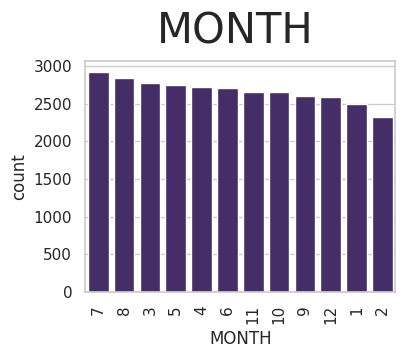





* Variable Analyzed: DAY
* Applied transformation: [] 



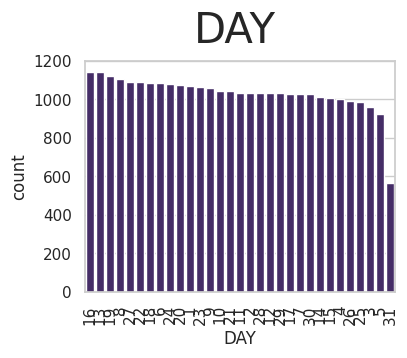





* Variable Analyzed: DAY_OF_WEEK
* Applied transformation: [] 



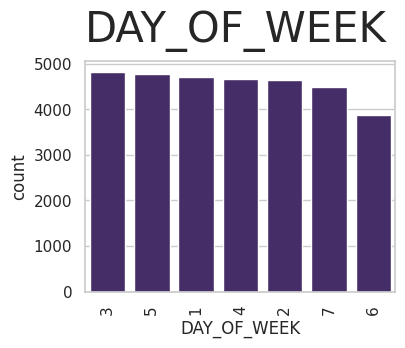





* Variable Analyzed: AIRLINE
* Applied transformation: ['AIRLINE_ordinal_encoder'] 



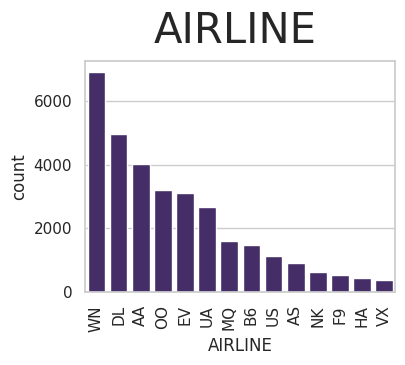

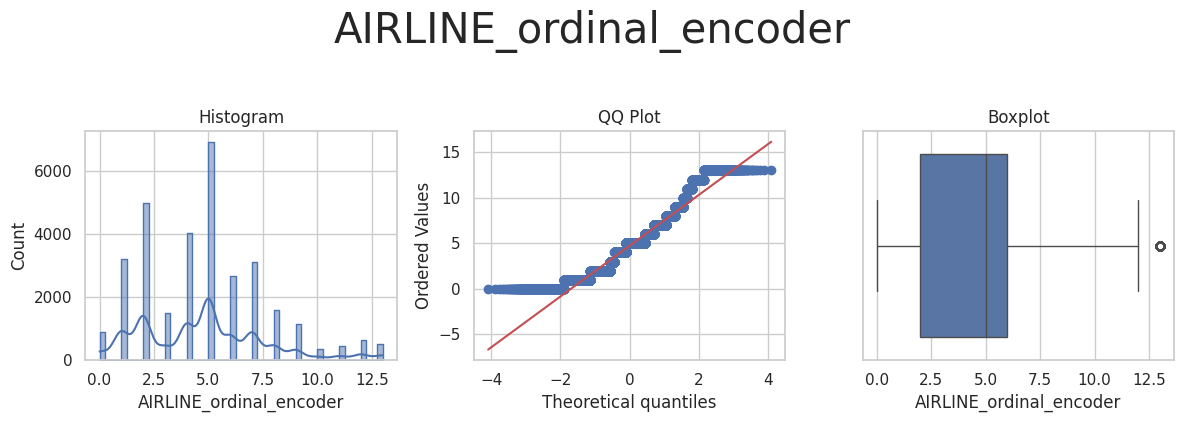



* Variable Analyzed: time_of_day
* Applied transformation: [] 



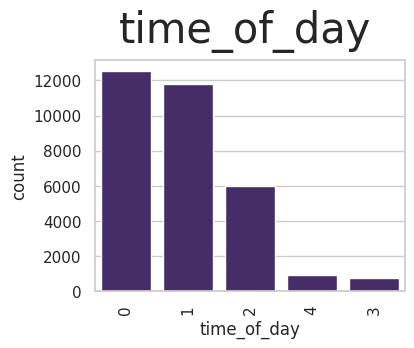





* Variable Analyzed: main_delay
* Applied transformation: ['main_delay_ordinal_encoder'] 



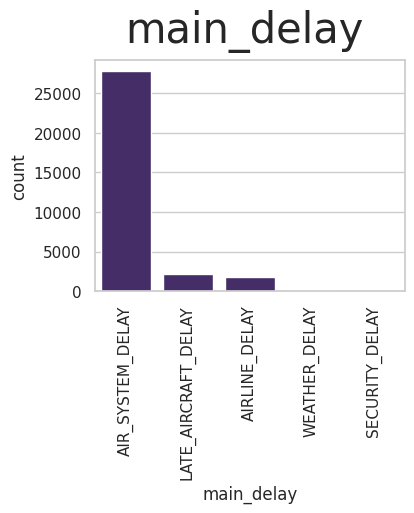

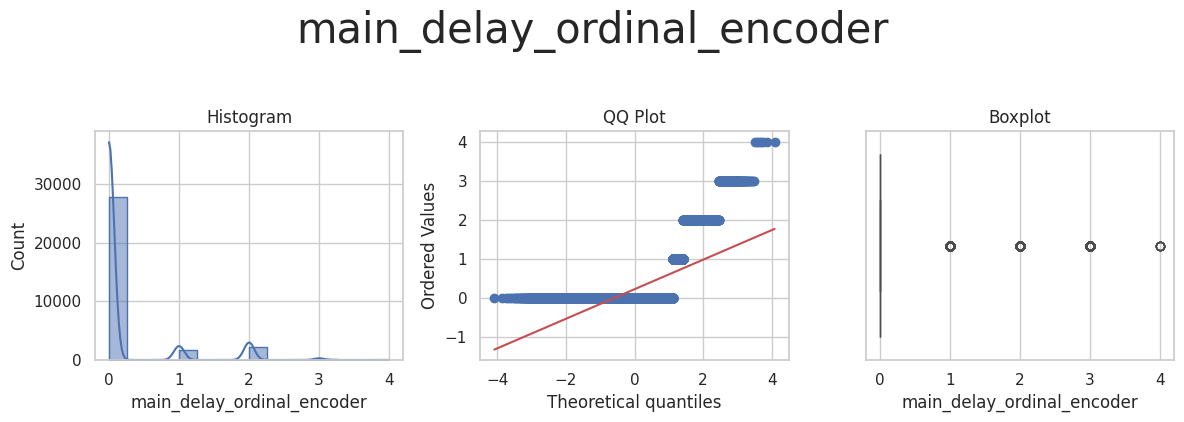

In [22]:
df_engineering = FeatureEngineeringAnalysis(df=df_engineering, analysis_type='ordinal_encoder')


**Apply selected transformations to Train and Test sets.**

In [14]:
encoder = OrdinalEncoder(encoding_method='arbitrary', variables = variables_engineering)
TrainSet = encoder.fit_transform(TrainSet)
TestSet = encoder.transform(TestSet)

print("* Categorical encoding - ordinal transformation done!")

* Categorical encoding - ordinal transformation done!


### Numerical Transformation

**Define variables to engineer**

In [23]:
TrainSet.columns

Index(['MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'DEPARTURE_DELAY', 'DISTANCE',
       'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY', 'flight_depart_delayed',
       'AIR_SYSTEM_DELAY_pct', 'SECURITY_DELAY_pct', 'AIRLINE_DELAY_pct',
       'LATE_AIRCRAFT_DELAY_pct', 'WEATHER_DELAY_pct', 'time_of_day',
       'main_delay'],
      dtype='object')

In [24]:
variables_engineering = ['DEPARTURE_DELAY', 'DISTANCE','AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY', 'flight_depart_delayed',
       'AIR_SYSTEM_DELAY_pct', 'SECURITY_DELAY_pct', 'AIRLINE_DELAY_pct',
       'LATE_AIRCRAFT_DELAY_pct', 'WEATHER_DELAY_pct',]
variables_engineering

['DEPARTURE_DELAY',
 'DISTANCE',
 'AIR_SYSTEM_DELAY',
 'SECURITY_DELAY',
 'AIRLINE_DELAY',
 'LATE_AIRCRAFT_DELAY',
 'WEATHER_DELAY',
 'flight_depart_delayed',
 'AIR_SYSTEM_DELAY_pct',
 'SECURITY_DELAY_pct',
 'AIRLINE_DELAY_pct',
 'LATE_AIRCRAFT_DELAY_pct',
 'WEATHER_DELAY_pct']

Define separate dataframe

In [26]:
df_engineering = TrainSet[variables_engineering].copy()
df_engineering.head(5)

,DEPARTURE_DELAY,DISTANCE,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,flight_depart_delayed,AIR_SYSTEM_DELAY_pct,SECURITY_DELAY_pct,AIRLINE_DELAY_pct,LATE_AIRCRAFT_DELAY_pct,WEATHER_DELAY_pct
0,18.0,1448,0.0,0.0,0.0,0.0,0.0,1,0.0,0.0,0.0,0.0,0.0
1,-5.0,584,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0
2,-6.0,224,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0
3,-4.0,1416,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0
4,-4.0,1023,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0


Create engineered variables from multiple transformations

* Variable Analyzed: DEPARTURE_DELAY
* Applied transformation: ['DEPARTURE_DELAY_power', 'DEPARTURE_DELAY_yeo_johnson'] 



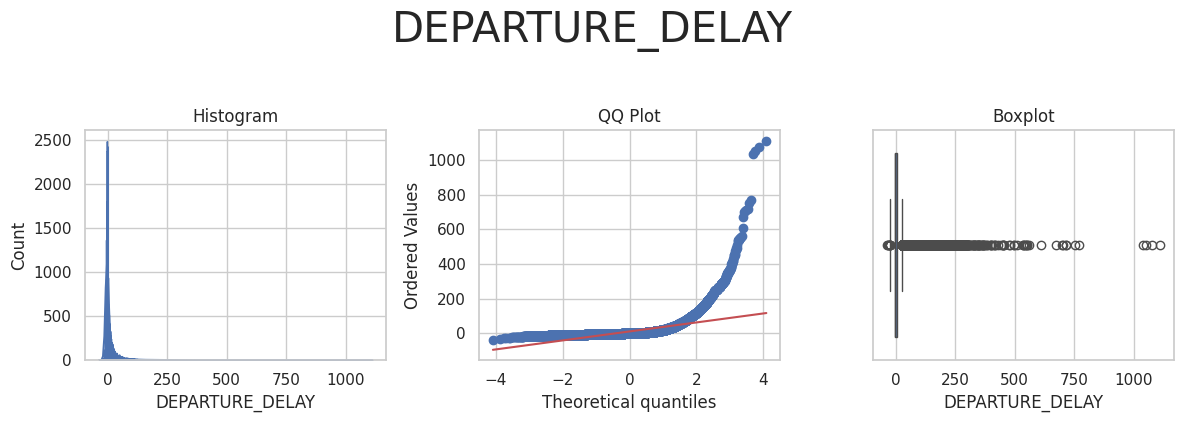

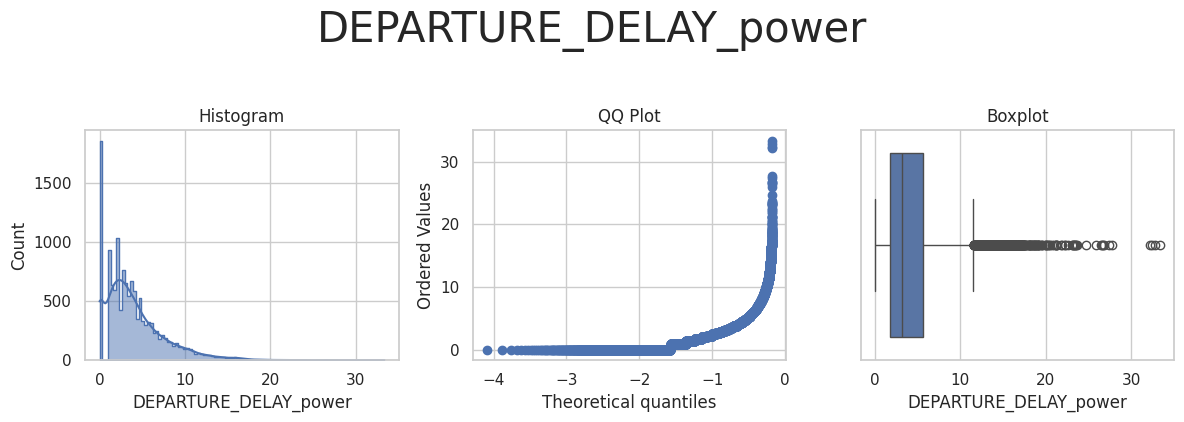

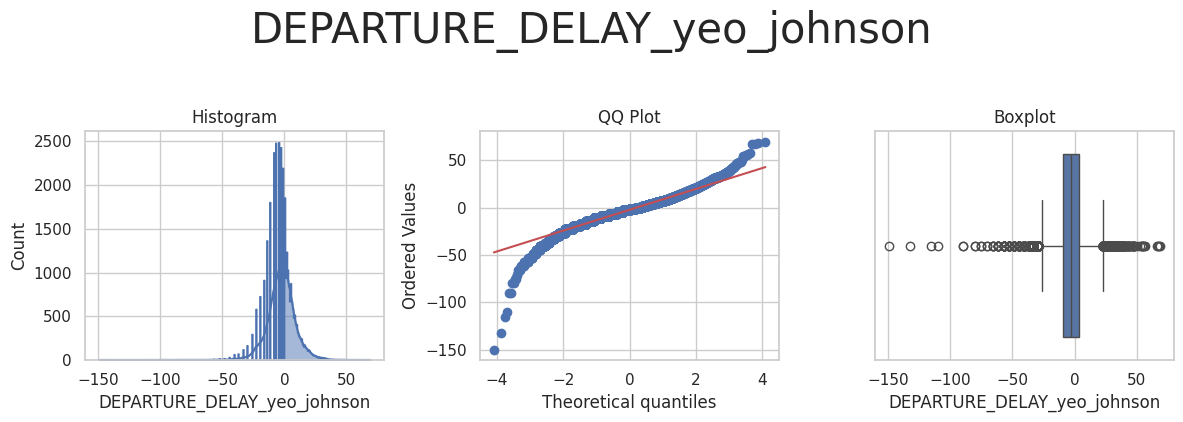



* Variable Analyzed: DISTANCE
* Applied transformation: ['DISTANCE_log_e', 'DISTANCE_log_10', 'DISTANCE_reciprocal', 'DISTANCE_power', 'DISTANCE_box_cox', 'DISTANCE_yeo_johnson'] 



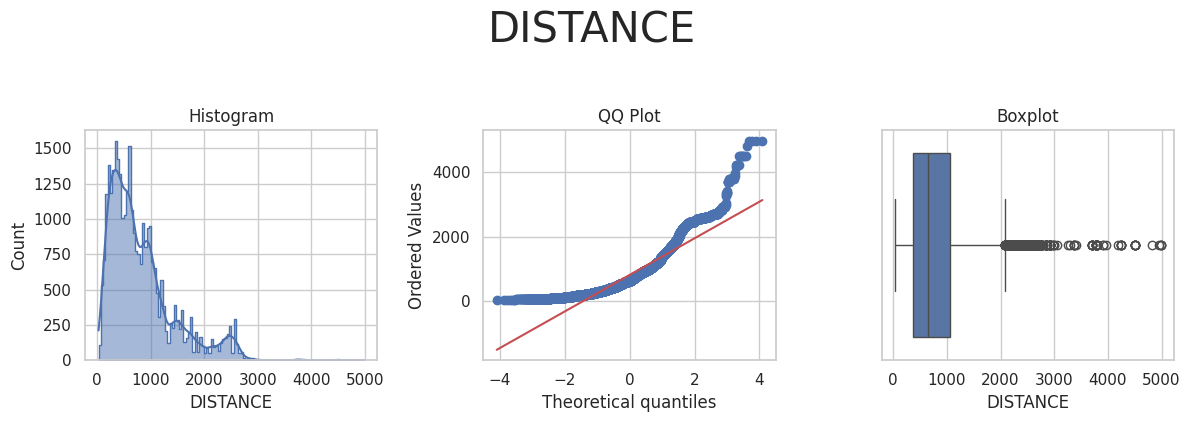

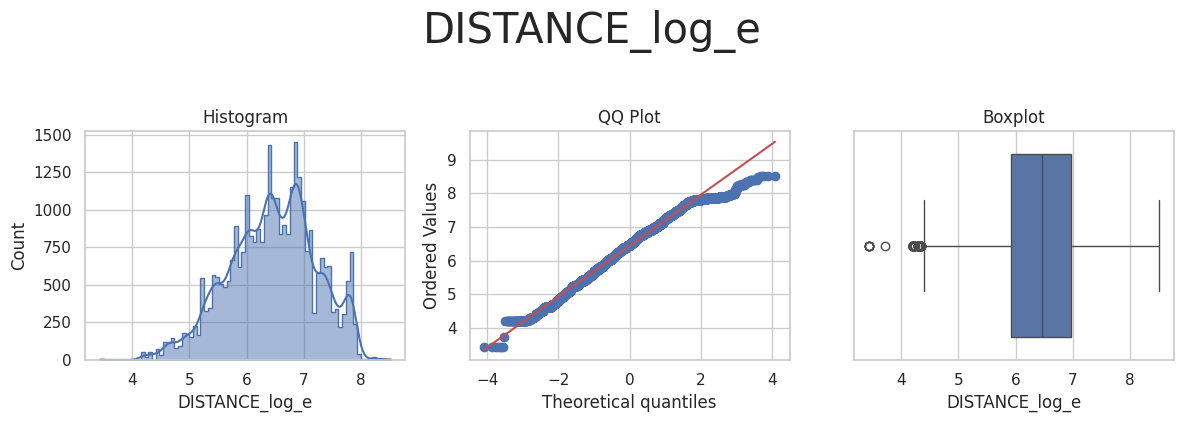

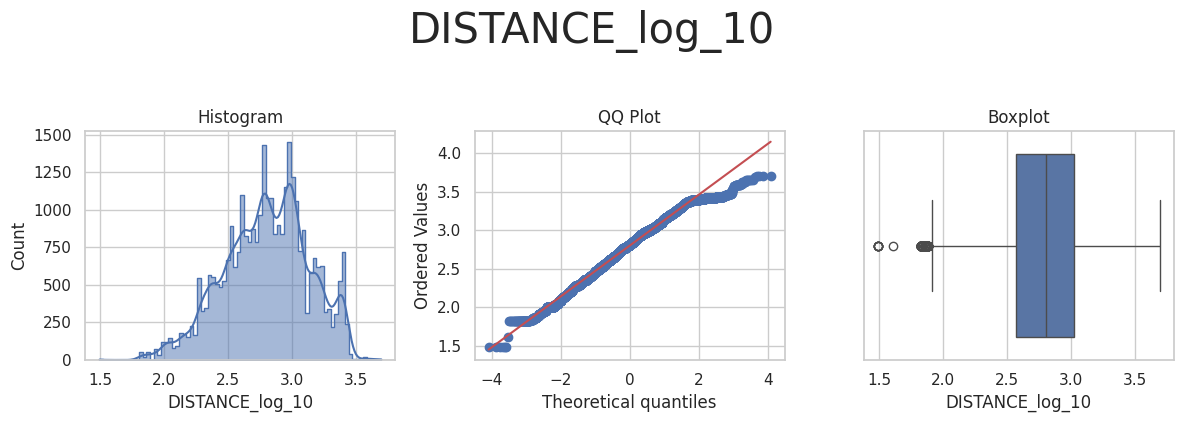

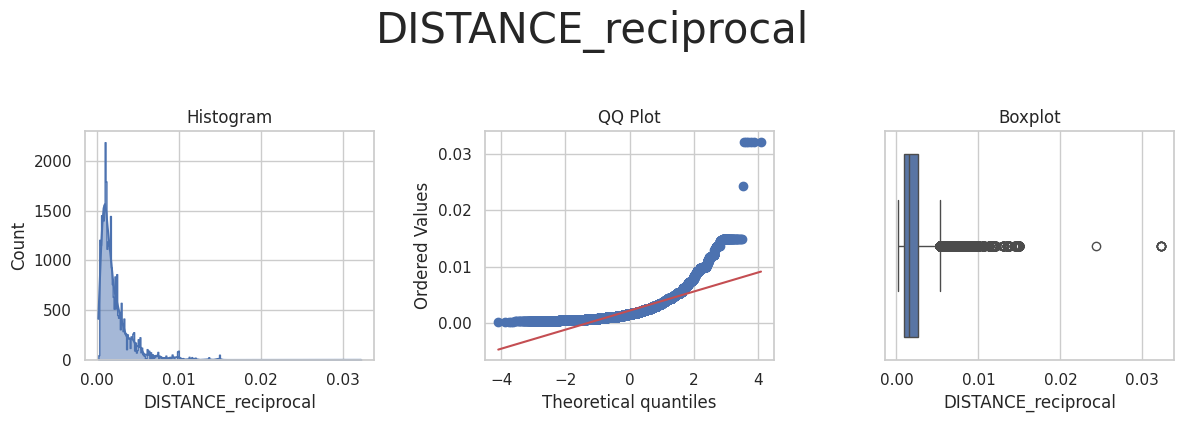

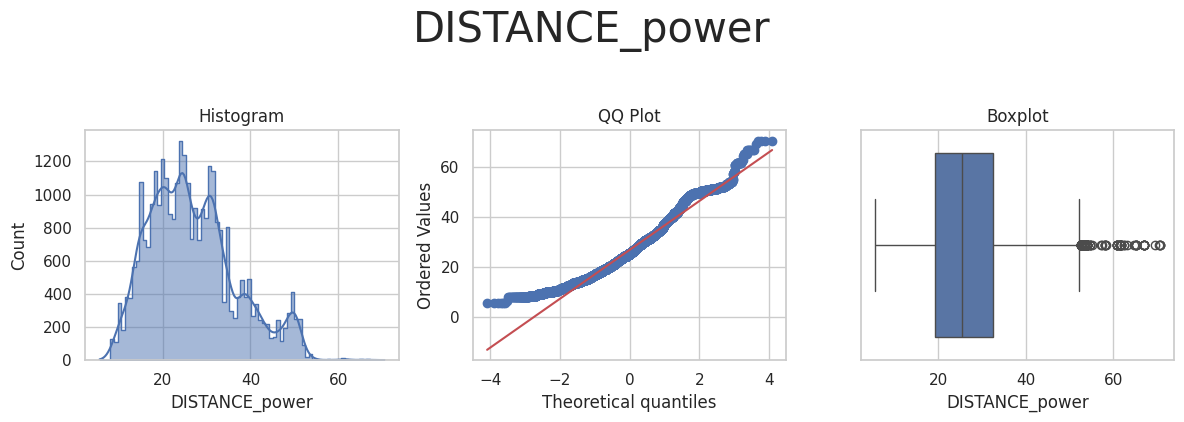

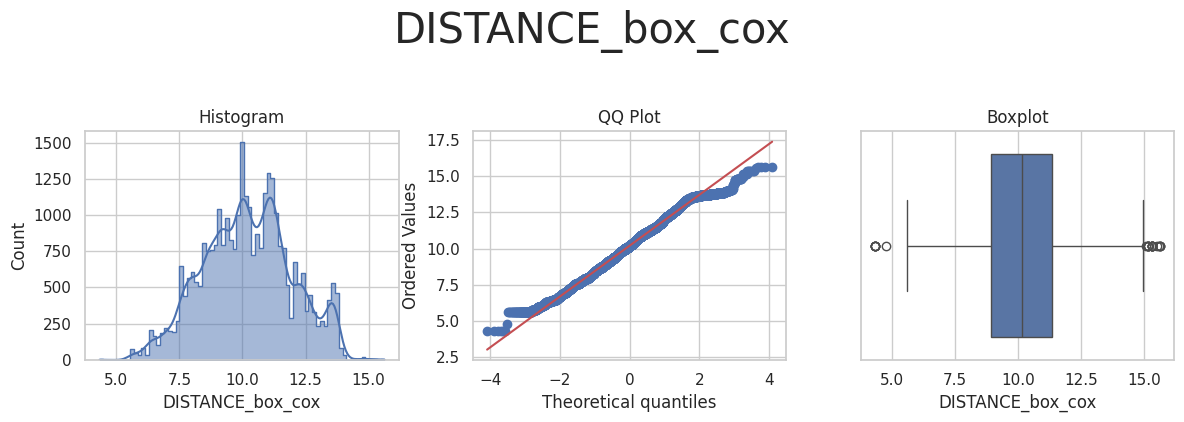

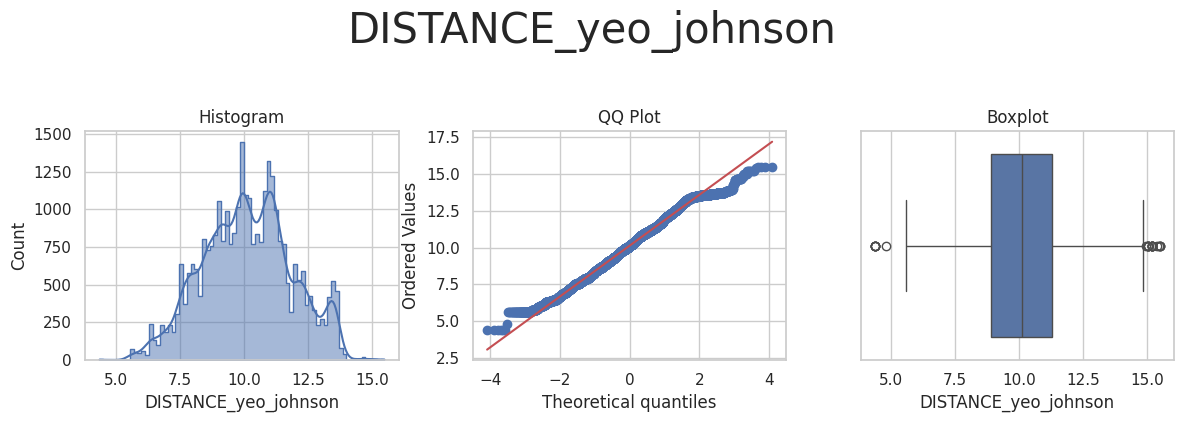



* Variable Analyzed: AIR_SYSTEM_DELAY
* Applied transformation: ['AIR_SYSTEM_DELAY_power', 'AIR_SYSTEM_DELAY_yeo_johnson'] 



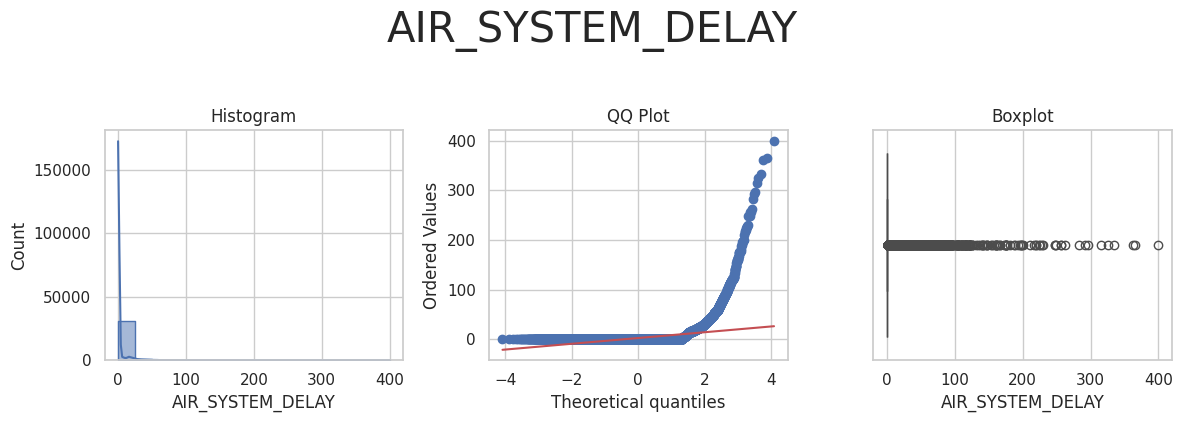

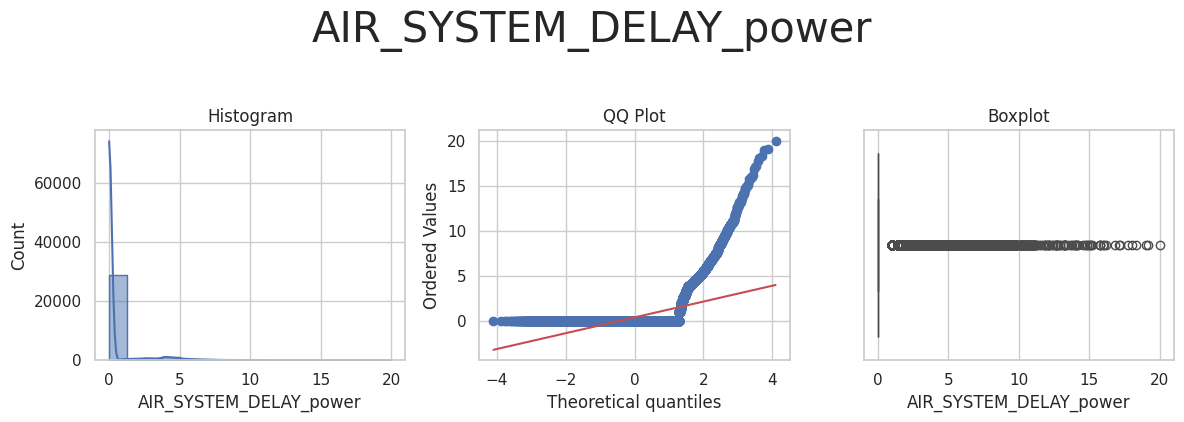

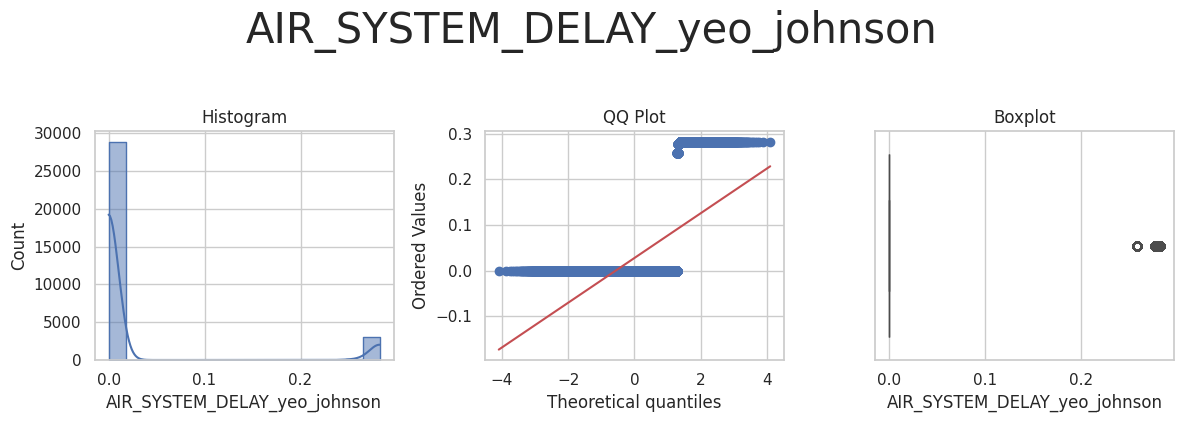



* Variable Analyzed: SECURITY_DELAY
* Applied transformation: ['SECURITY_DELAY_power', 'SECURITY_DELAY_yeo_johnson'] 



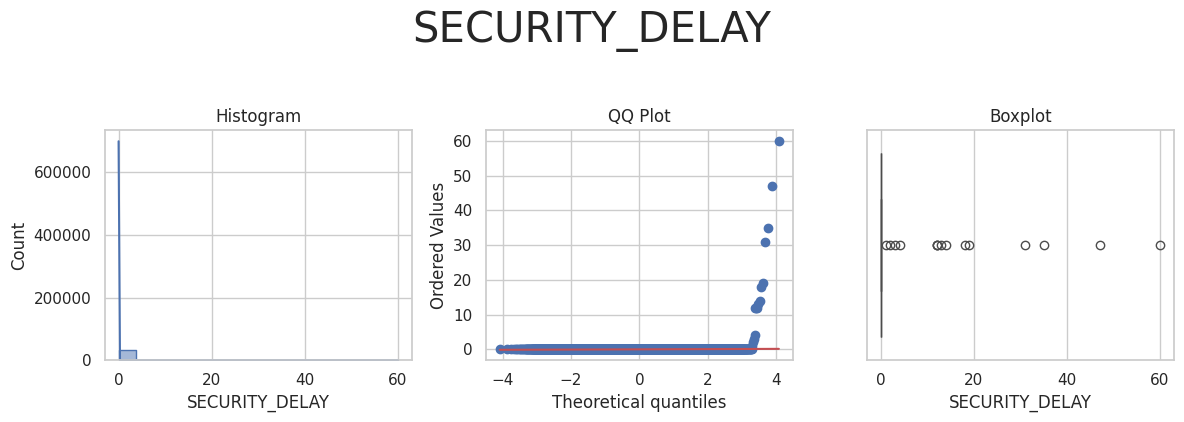

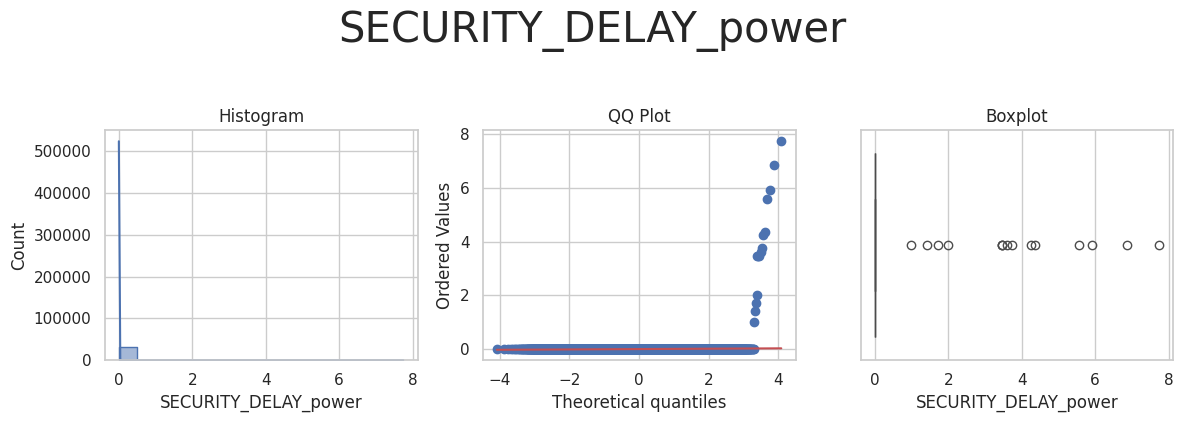

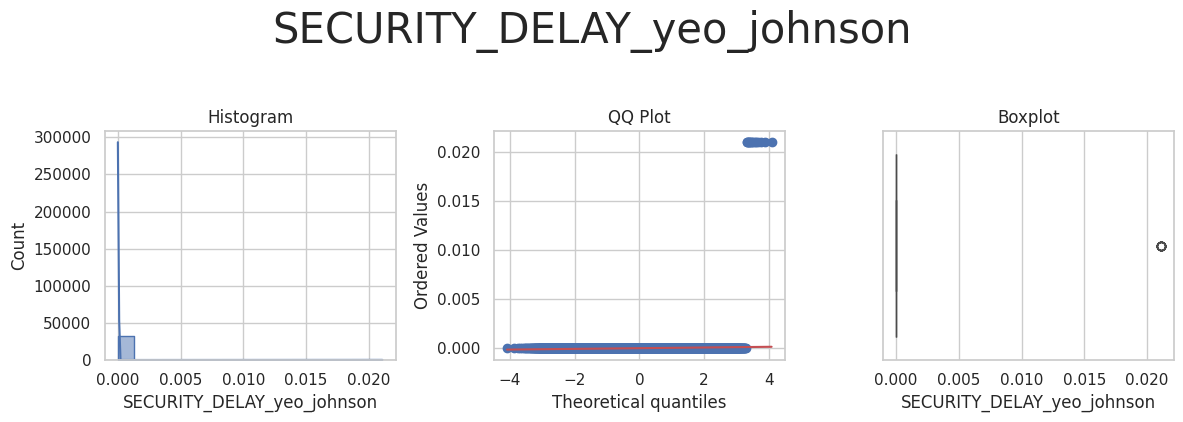



* Variable Analyzed: AIRLINE_DELAY
* Applied transformation: ['AIRLINE_DELAY_power', 'AIRLINE_DELAY_yeo_johnson'] 



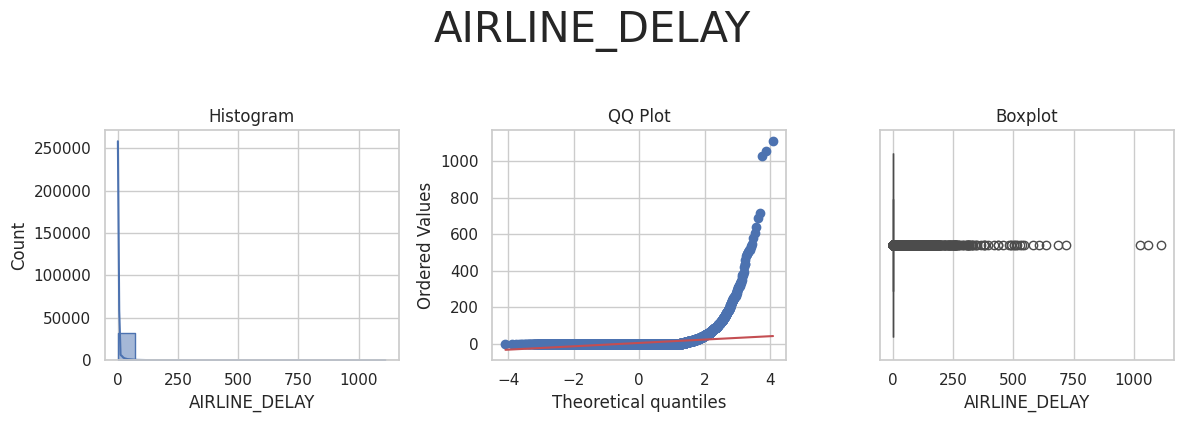

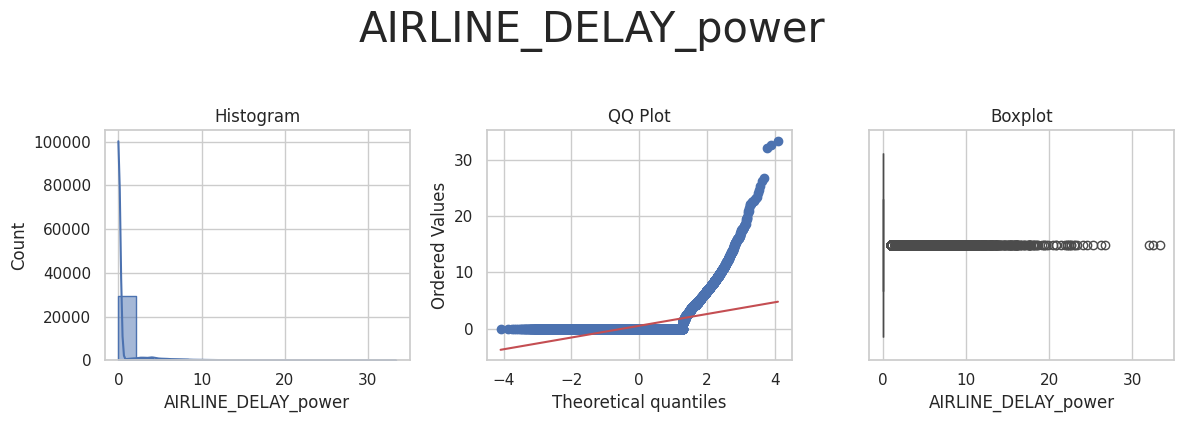

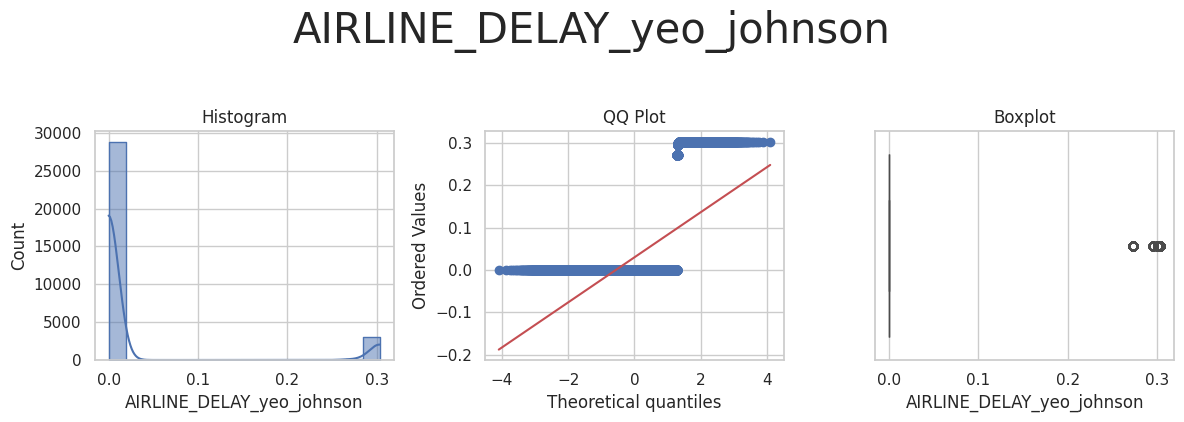



* Variable Analyzed: LATE_AIRCRAFT_DELAY
* Applied transformation: ['LATE_AIRCRAFT_DELAY_power', 'LATE_AIRCRAFT_DELAY_yeo_johnson'] 



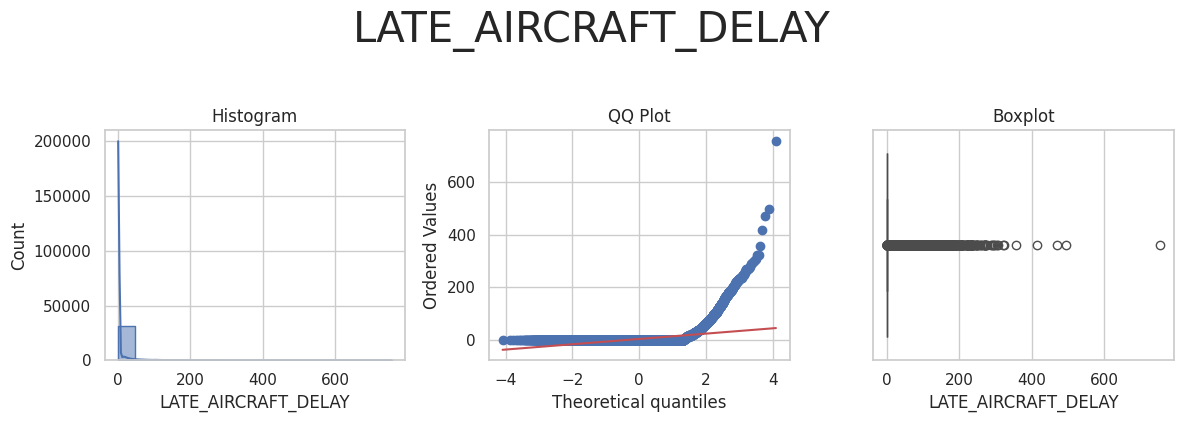

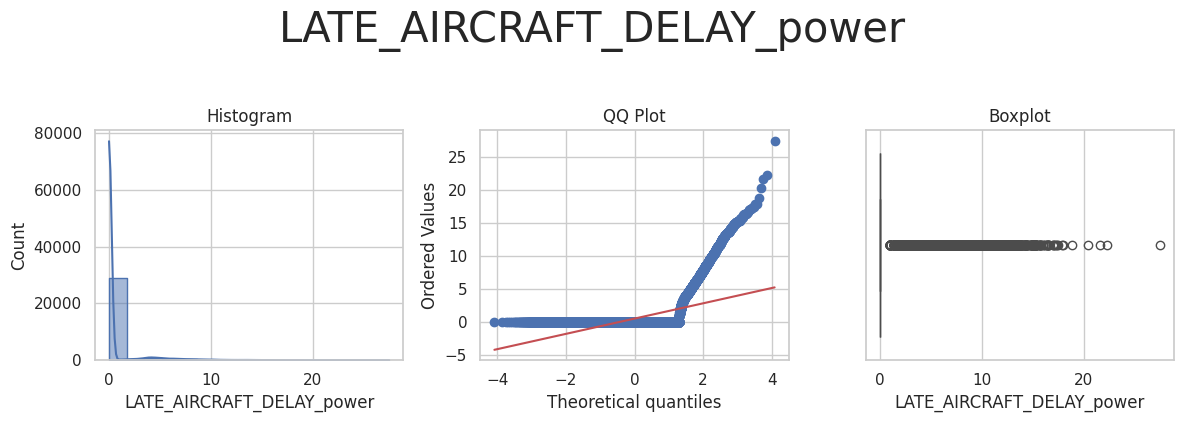

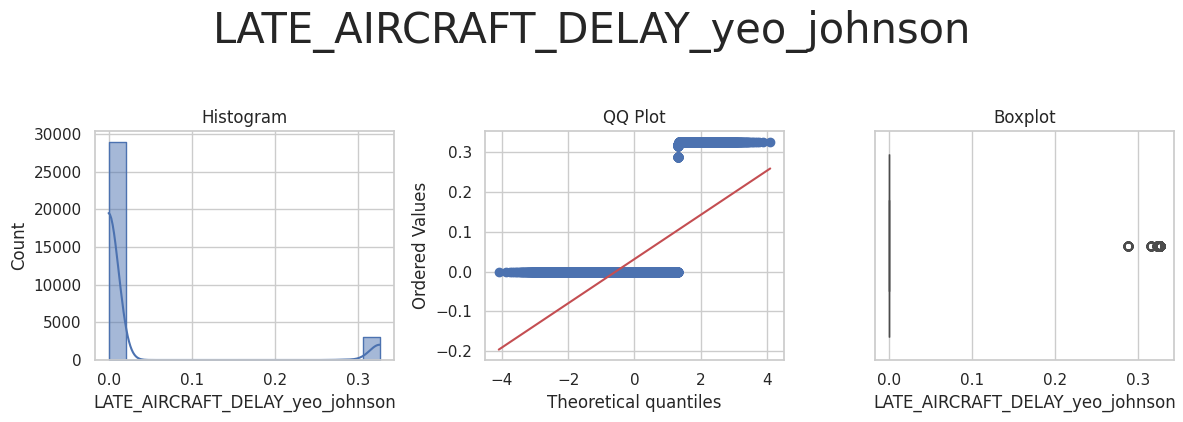



* Variable Analyzed: WEATHER_DELAY
* Applied transformation: ['WEATHER_DELAY_power', 'WEATHER_DELAY_yeo_johnson'] 



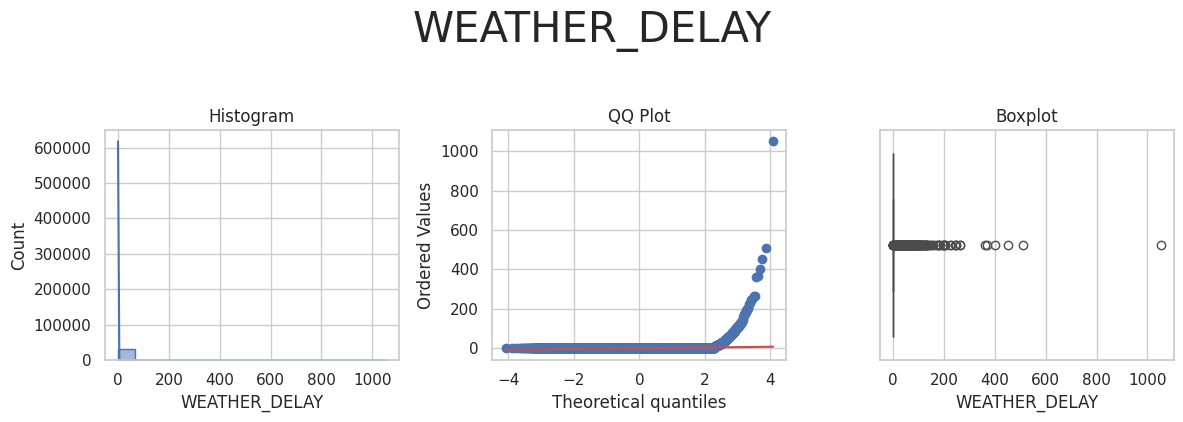

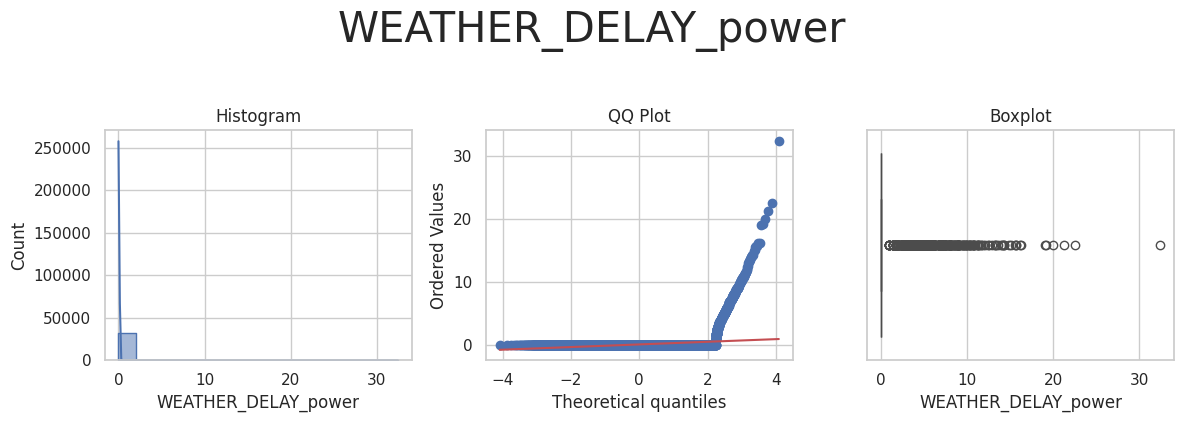

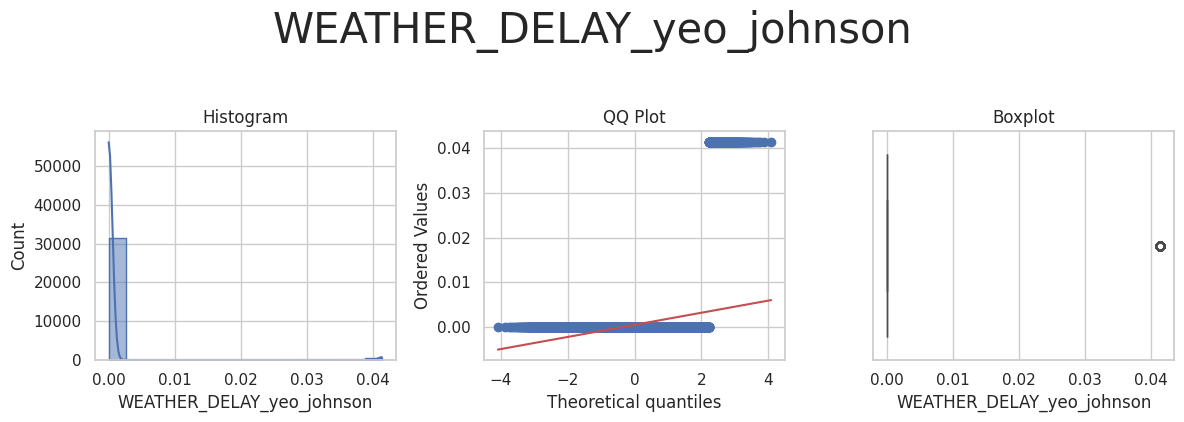



* Variable Analyzed: flight_depart_delayed
* Applied transformation: ['flight_depart_delayed_power', 'flight_depart_delayed_yeo_johnson'] 



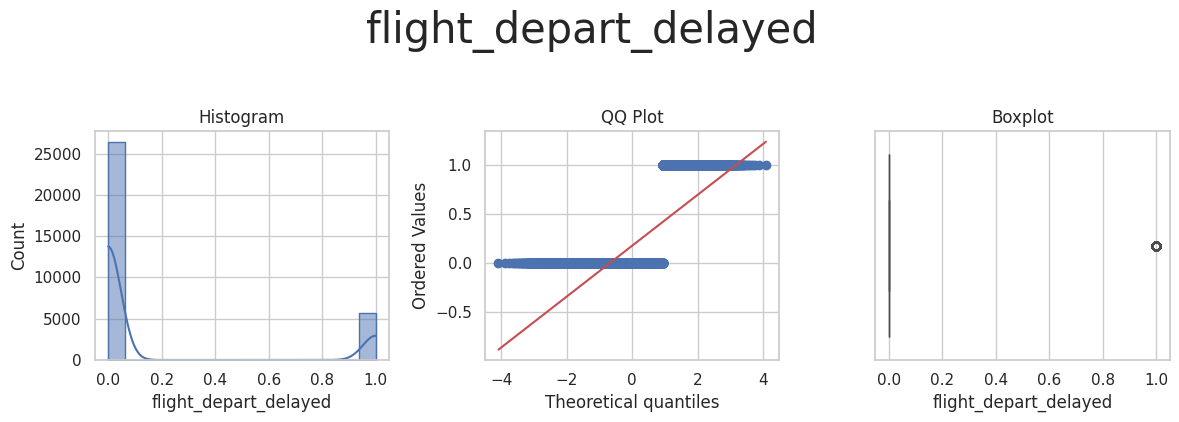

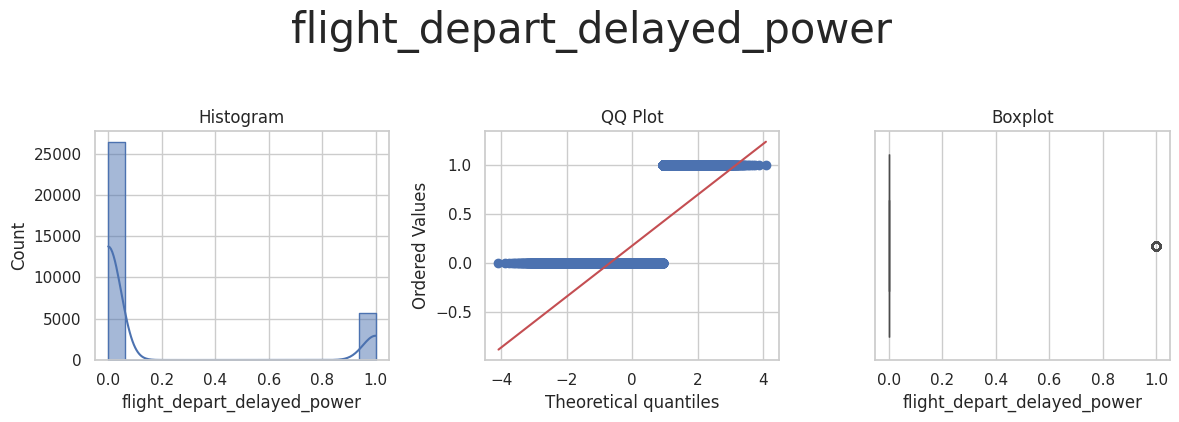

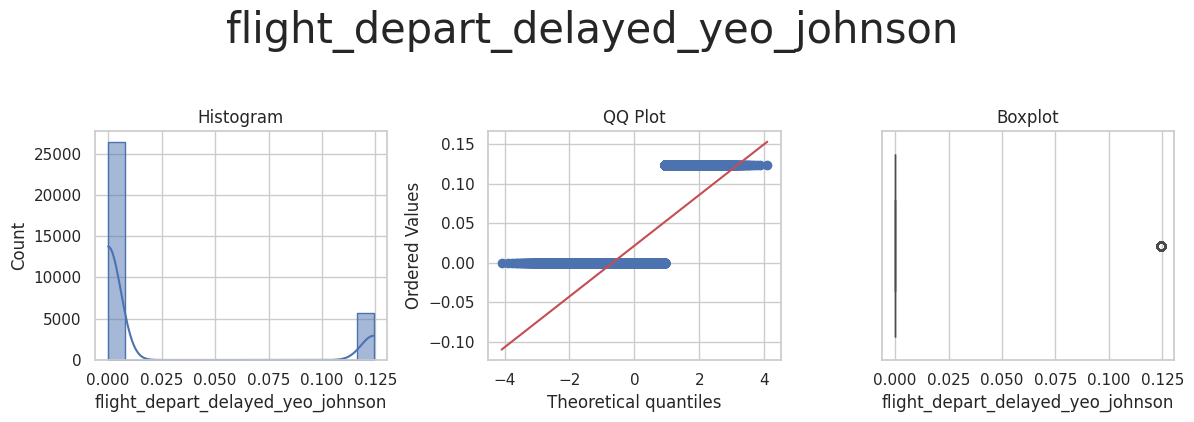



* Variable Analyzed: AIR_SYSTEM_DELAY_pct
* Applied transformation: [] 



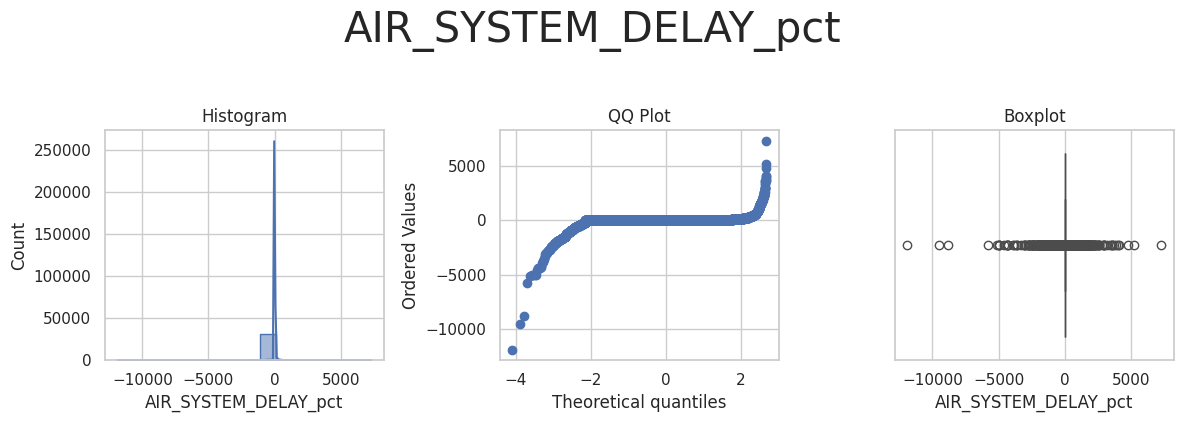



* Variable Analyzed: SECURITY_DELAY_pct
* Applied transformation: ['SECURITY_DELAY_pct_power', 'SECURITY_DELAY_pct_yeo_johnson'] 



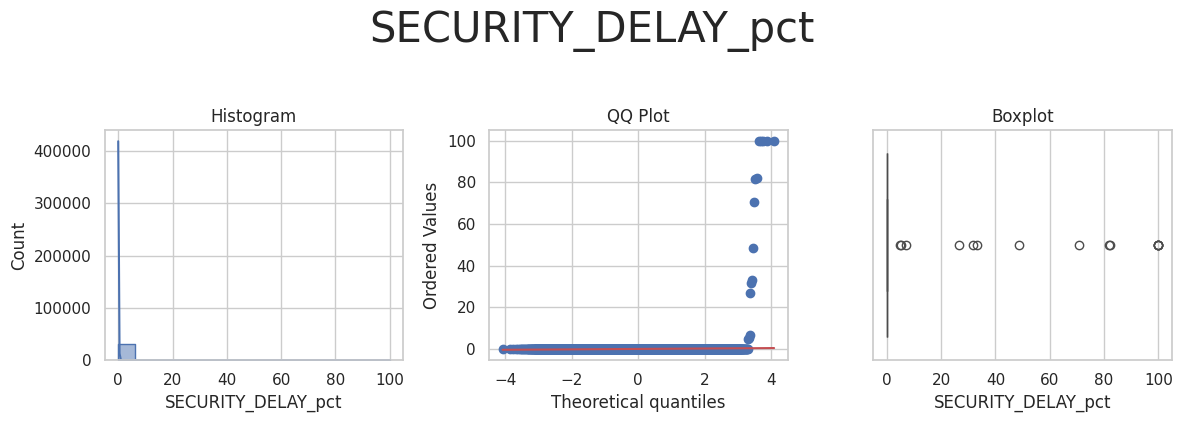

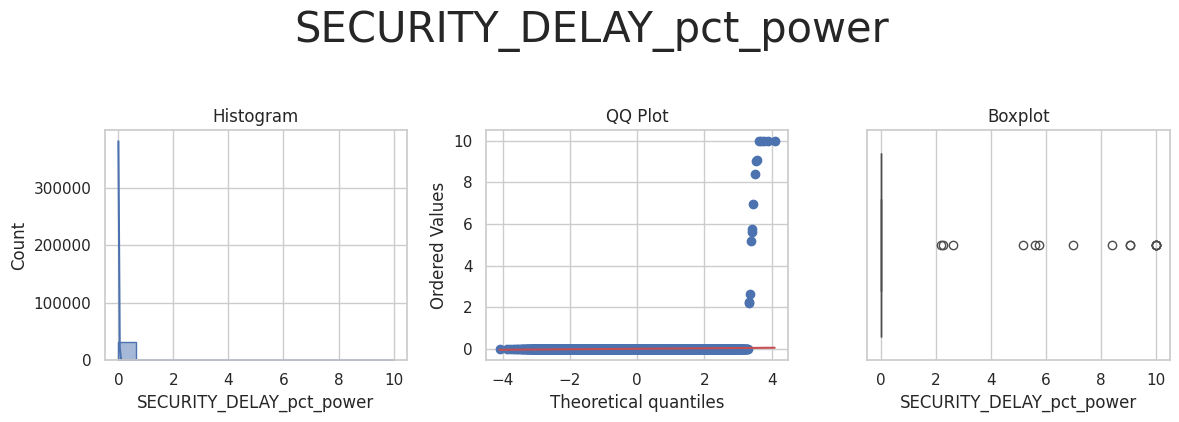

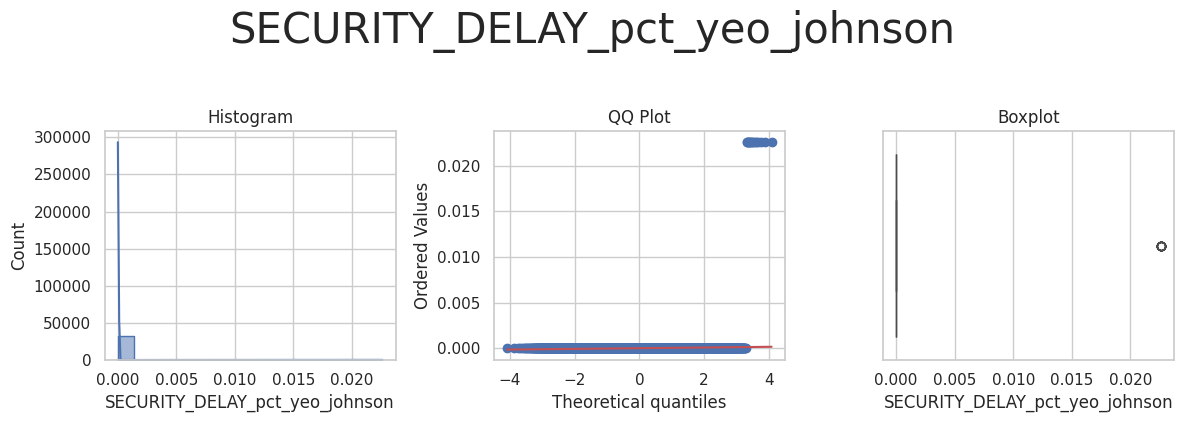



* Variable Analyzed: AIRLINE_DELAY_pct
* Applied transformation: [] 



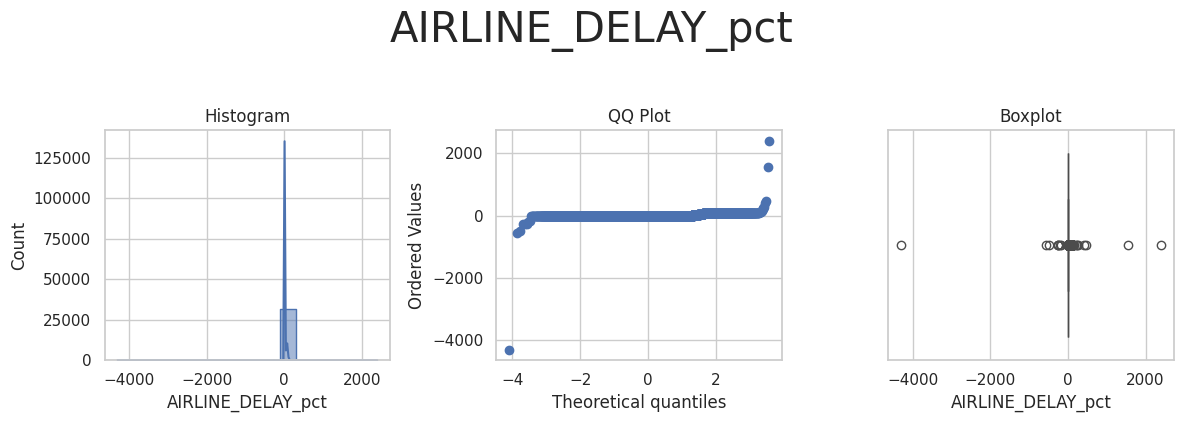



* Variable Analyzed: LATE_AIRCRAFT_DELAY_pct
* Applied transformation: ['LATE_AIRCRAFT_DELAY_pct_power', 'LATE_AIRCRAFT_DELAY_pct_yeo_johnson'] 



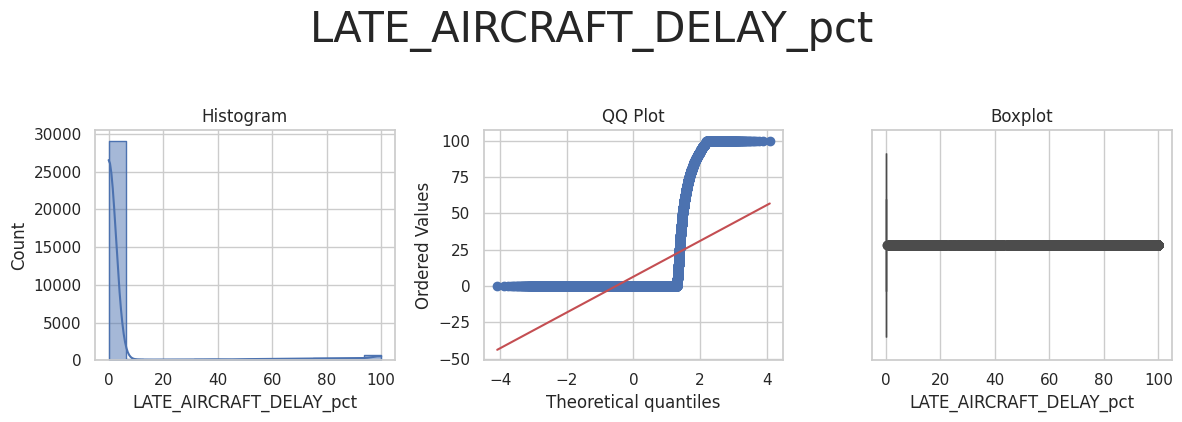

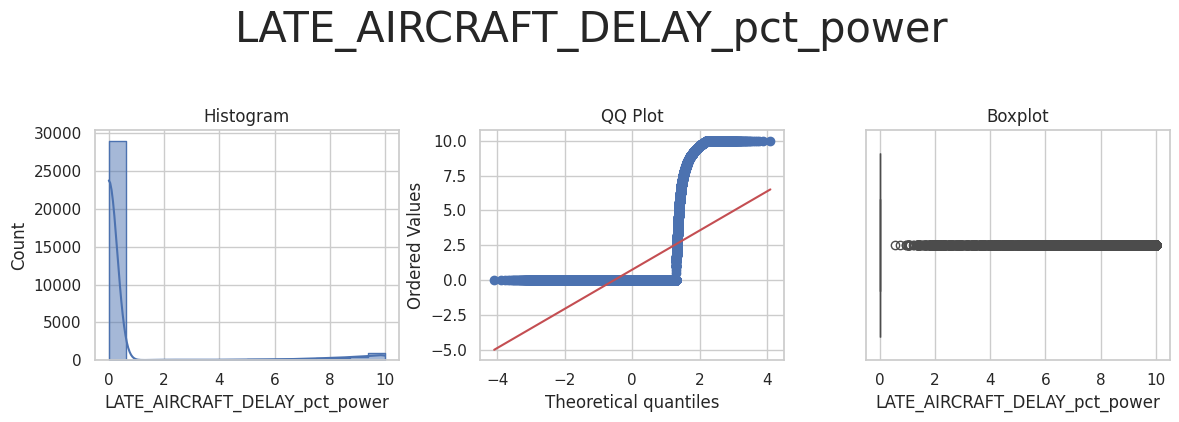

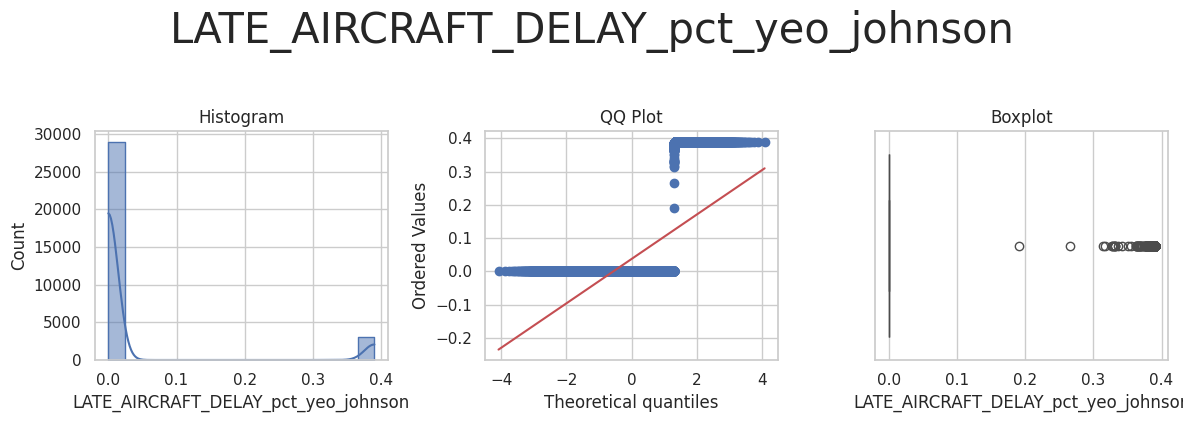



* Variable Analyzed: WEATHER_DELAY_pct
* Applied transformation: [] 



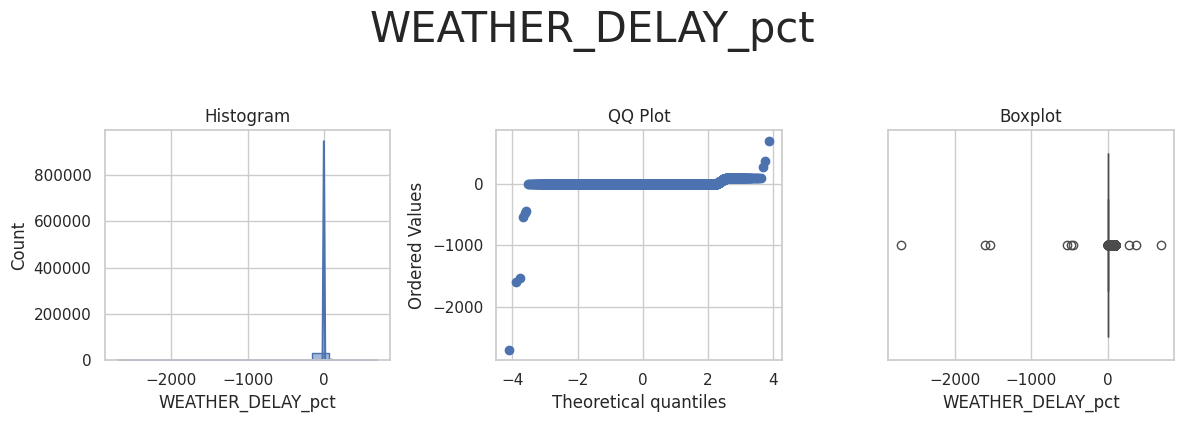

In [27]:
df_engineering = FeatureEngineeringAnalysis(df=df_engineering, analysis_type='numerical')

**Numerical Transformation Outcome:** None of the variables improved.

### SmartCorrelatedSelection Variables

All variables will be used.
Create a separate dataframe

In [28]:

df_engineering = TrainSet.copy()
df_engineering.head(5)

,MONTH,DAY,DAY_OF_WEEK,AIRLINE,DEPARTURE_DELAY,DISTANCE,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,flight_depart_delayed,AIR_SYSTEM_DELAY_pct,SECURITY_DELAY_pct,AIRLINE_DELAY_pct,LATE_AIRCRAFT_DELAY_pct,WEATHER_DELAY_pct,time_of_day,main_delay
0,7,8,3,AS,18.0,1448,0.0,0.0,0.0,0.0,0.0,1,0.0,0.0,0.0,0.0,0.0,0,AIR_SYSTEM_DELAY
1,1,22,4,OO,-5.0,584,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,1,AIR_SYSTEM_DELAY
2,5,29,5,OO,-6.0,224,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0,AIR_SYSTEM_DELAY
3,4,7,2,DL,-4.0,1416,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0,AIR_SYSTEM_DELAY
4,8,9,7,B6,-4.0,1023,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0,AIR_SYSTEM_DELAY


Create engineered variables using SmartCorrelationSelection

In [29]:
from feature_engine.selection import SmartCorrelatedSelection
corr_sel = SmartCorrelatedSelection(variables=None, method="spearman", threshold=0.6, selection_method="variance")

corr_sel.fit_transform(df_engineering)
corr_sel.correlated_feature_sets_

[{'DEPARTURE_DELAY', 'flight_depart_delayed'},
 {'AIR_SYSTEM_DELAY', 'AIR_SYSTEM_DELAY_pct'},
 {'SECURITY_DELAY', 'SECURITY_DELAY_pct'},
 {'AIRLINE_DELAY', 'AIRLINE_DELAY_pct'},
 {'LATE_AIRCRAFT_DELAY', 'LATE_AIRCRAFT_DELAY_pct'},
 {'WEATHER_DELAY', 'WEATHER_DELAY_pct'}]

In [30]:
# Features to drop
corr_sel.features_to_drop_

['SECURITY_DELAY',
 'flight_depart_delayed',
 'AIR_SYSTEM_DELAY_pct',
 'AIRLINE_DELAY_pct',
 'LATE_AIRCRAFT_DELAY_pct',
 'WEATHER_DELAY_pct']

---

# Conclusions and Next Steps

Feature Engineering Transformers require in the ML pipeline:

* Ordinal categorical encoding: ['MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE','time_of_day','main_delay']

* Smart Correlation Selection: ['SECURITY_DELAY', 'flight_depart_delayed' 'AIR_SYSTEM_DELAY_pct', 'AIRLINE_DELAY_pct', 'LATE_AIRCRAFT_DELAY_pct', 'WEATHER_DELAY_pct']